# Task - 02

Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("C://Users//srivi//Downloads//Mall_Customers.csv")
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [55]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [56]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

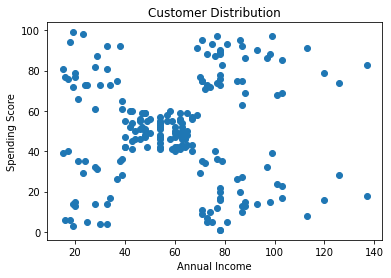

In [57]:
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

In [58]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

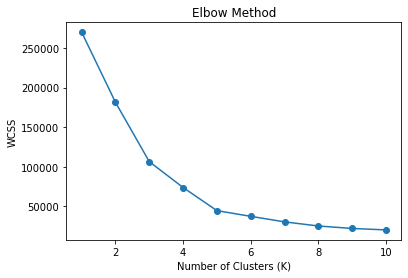

In [59]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [60]:
kmeans = KMeans(n_clusters=5, random_state=42,n_init=10)

y_kmeans = kmeans.fit_predict(X)

In [61]:
df['Cluster'] = y_kmeans

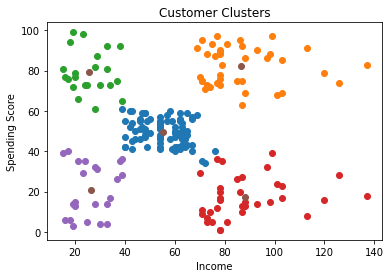

In [62]:
plt.scatter(X[y_kmeans == 0]['Annual Income (k$)'],
            X[y_kmeans == 0]['Spending Score (1-100)'])

plt.scatter(X[y_kmeans == 1]['Annual Income (k$)'],
            X[y_kmeans == 1]['Spending Score (1-100)'])

plt.scatter(X[y_kmeans == 2]['Annual Income (k$)'],
            X[y_kmeans == 2]['Spending Score (1-100)'])

plt.scatter(X[y_kmeans == 3]['Annual Income (k$)'],
            X[y_kmeans == 3]['Spending Score (1-100)'])

plt.scatter(X[y_kmeans == 4]['Annual Income (k$)'],
            X[y_kmeans == 4]['Spending Score (1-100)'])


plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1])

plt.title("Customer Clusters")
plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.show()

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [65]:
print(kmeans.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [66]:
df.groupby('Cluster')['CustomerID'].count()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: CustomerID, dtype: int64